<a href="https://colab.research.google.com/github/VukasinA/ML_projekti/blob/main/DubokoUcenjeVADom1111.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""PetFinder AdoptionSpeed - Colab/Jupyter notebook
Auto-generated notebook. Split into runnable cells.
Instructions:
1) Upload the 'data' folder to /content/data or clone the repo and set DATA_DIR accordingly.
2) Install dependencies if needed (uncomment pip install cell).
3) Run cells in order.
"""

# %%
# Set DATA_DIR: adjust if you cloned the repo or mounted Drive
!git clone https://github.com/MilanBojic1999/RAF-PetFinder-dataset.git
DATA_DIR = 'RAF-PetFinder-dataset/Data'  # change to 'RAF-PetFinder-dataset/data' if you cloned the repo

# If using Google Drive, mount it and change DATA_DIR accordingly.
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/path_to_data'

Cloning into 'RAF-PetFinder-dataset'...
remote: Enumerating objects: 88478, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 88478 (delta 3), reused 10 (delta 3), pack-reused 88466 (from 1)
Receiving objects: 100% (88478/88478), 1.81 GiB | 20.21 MiB/s, done.
Resolving deltas: 100% (17187/17187), done.
Updating files: 100% (91619/91619), done.


In [ ]:
# Install dependencies (uncomment to run in Colab)
!pip install -q lightgbm scikit-learn torch torchvision matplotlib seaborn joblib opencv-python scipy


In [ ]:
# Imports and seeds
import os
import random
import glob
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score

import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from scipy.stats import skew, kurtosis

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)


DEVICE = cpu


In [ ]:
# Load CSVs
print('Looking for data in', DATA_DIR)
train_csv = os.path.join(DATA_DIR, 'train.csv')
train_sentiment_csv = os.path.join(DATA_DIR, 'train_sentiment.csv')
images_dir = os.path.join(DATA_DIR, 'train_images')

assert os.path.exists(train_csv), f"train.csv not found in {DATA_DIR}"
train = pd.read_csv(train_csv)
print('train shape', train.shape)

if os.path.exists(train_sentiment_csv):
    sent = pd.read_csv(train_sentiment_csv)
    print('sentiment shape', sent.shape)
    train = train.merge(sent, on='PetID', how='left')
else:
    train['SentimentScore'] = 0.0
    train['SentimentMagnitude'] = 0.0

train.head()


Looking for data in RAF-PetFinder-dataset/Data
train shape (14993, 24)
sentiment shape (14442, 3)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,SentimentScore,SentimentMagnitude
0,2,Nibble,3,299,0,1,1,7,0,1,...,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2,0.3,2.4
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0,-0.2,0.7
2,1,Brisco,1,307,0,1,2,7,0,2,...,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3,0.2,3.7
3,1,Miko,4,307,0,2,1,2,0,2,...,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2,0.9,0.9
4,1,Hunter,1,307,0,1,1,0,0,2,...,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2,0.6,3.7


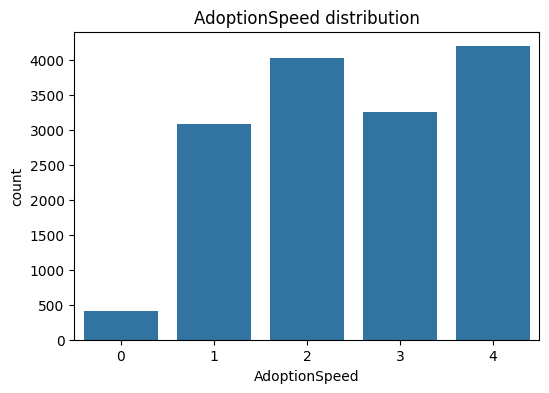

AdoptionSpeed
0    0.027346
1    0.206096
2    0.269259
3    0.217368
4    0.279931
Name: proportion, dtype: float64


In [ ]:
# Basic EDA: target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='AdoptionSpeed', data=train, order=sorted(train['AdoptionSpeed'].unique()))
plt.title('AdoptionSpeed distribution')
plt.show()

print(train['AdoptionSpeed'].value_counts(normalize=True).sort_index())


<Figure size 800x400 with 0 Axes>

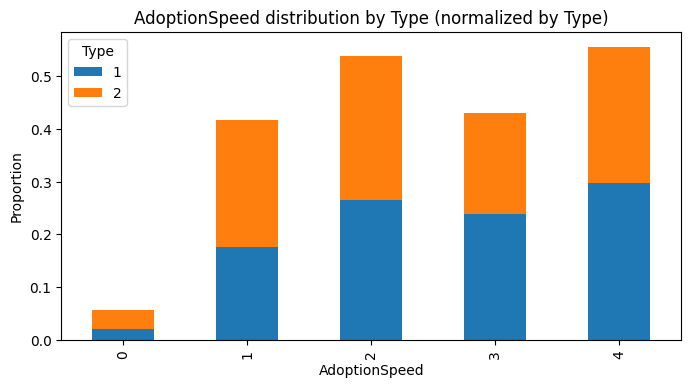

In [ ]:
# Type vs AdoptionSpeed
plt.figure(figsize=(8,4))
ct = pd.crosstab(train['Type'], train['AdoptionSpeed'], normalize='index')
ct.T.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title('AdoptionSpeed distribution by Type (normalized by Type)')
plt.xlabel('AdoptionSpeed')
plt.ylabel('Proportion')
plt.show()


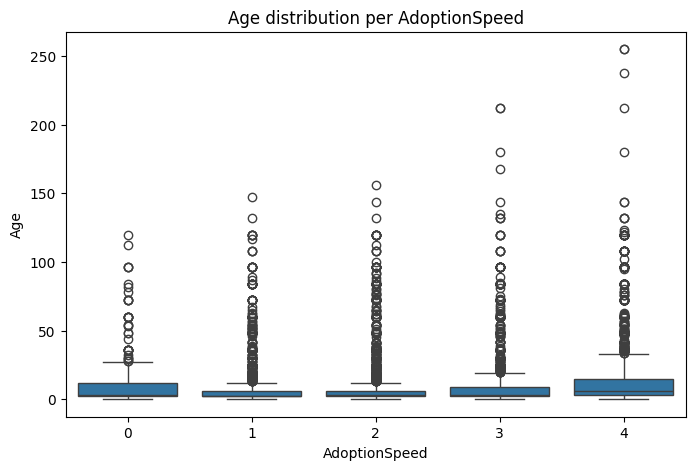

   AdoptionSpeed  count       mean        std      skew   kurtosis
0              0    410  10.451220  17.775118  3.243181  11.803355
1              1   3090   8.488350  15.746187  3.569619  15.565676
2              2   4037   8.823631  16.779013  3.587014  14.813989
3              3   3259  10.189936  18.672104  3.900499  21.031612
4              4   4197  13.667858  20.177460  3.782948  23.492990


In [ ]:
# Age vs AdoptionSpeed (boxplot) + corrected stats using scipy for skew/kurtosis
plt.figure(figsize=(8,5))
sns.boxplot(x='AdoptionSpeed', y='Age', data=train)
plt.title('Age distribution per AdoptionSpeed')
plt.show()

# compute mean, std, skew, kurtosis per class robustly
train['Age'] = train['Age'].fillna(0)

groups = train.groupby('AdoptionSpeed')['Age']
stats_age = pd.DataFrame({
    'AdoptionSpeed': groups.mean().index,
    'count': groups.count().values,
    'mean': groups.mean().values,
    'std': groups.std().values,
    'skew': groups.apply(lambda x: float(skew(x.dropna()))).values,
    'kurtosis': groups.apply(lambda x: float(kurtosis(x.dropna()))).values
}).reset_index(drop=True)

print(stats_age)


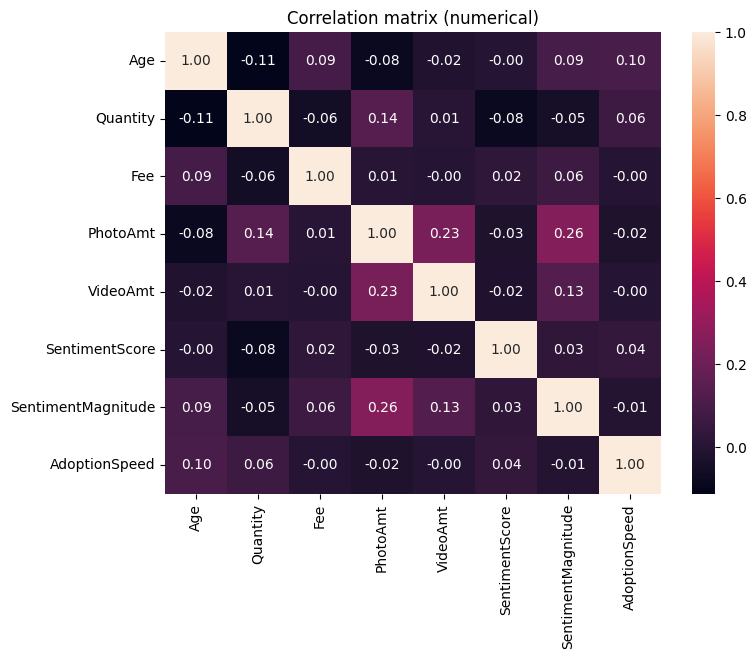

In [ ]:
# Numeric correlation heatmap
num_cols = ['Age','Quantity','Fee','PhotoAmt','VideoAmt','SentimentScore','SentimentMagnitude','AdoptionSpeed']
plt.figure(figsize=(8,6))
cm = train[num_cols].corr()
sns.heatmap(cm, annot=True, fmt='.2f')
plt.title('Correlation matrix (numerical)')
plt.show()


Total image files found: 58311


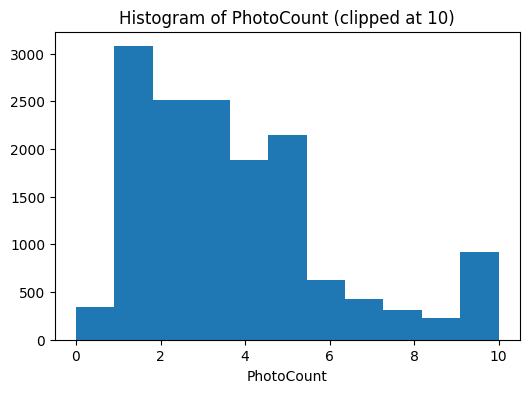

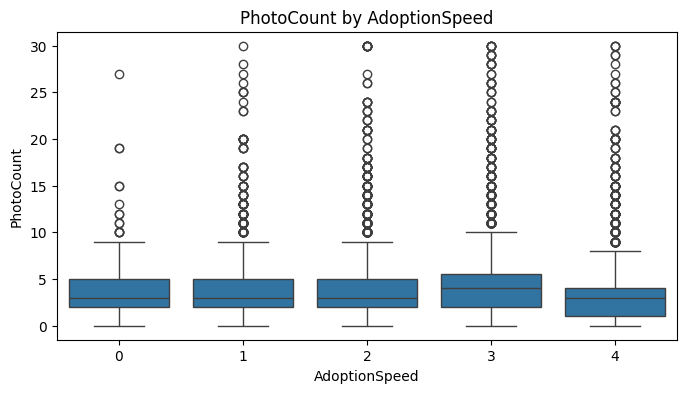

In [ ]:
# Image-based analysis 1: count image files and PhotoCount per PetID
all_files = glob.glob(os.path.join(images_dir, '*.jpg')) if os.path.exists(images_dir) else []
print('Total image files found:', len(all_files))

img_counts = Counter()
for f in all_files:
    fname = os.path.basename(f)
    petid = fname.split('-')[0]
    img_counts[petid] += 1

img_count_df = pd.DataFrame.from_records(list(img_counts.items()), columns=['PetID','PhotoCount'])
train = train.merge(img_count_df, on='PetID', how='left')
train['PhotoCount'] = train['PhotoCount'].fillna(0).astype(int)

plt.figure(figsize=(6,4))
plt.hist(train['PhotoCount'].clip(0,10), bins=11)
plt.title('Histogram of PhotoCount (clipped at 10)')
plt.xlabel('PhotoCount')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='AdoptionSpeed', y='PhotoCount', data=train)
plt.title('PhotoCount by AdoptionSpeed')
plt.show()


   cls  mean_brightness
0    0       108.867791
1    1       136.746761
2    2       142.733138
3    3       129.446497
4    4       102.366081


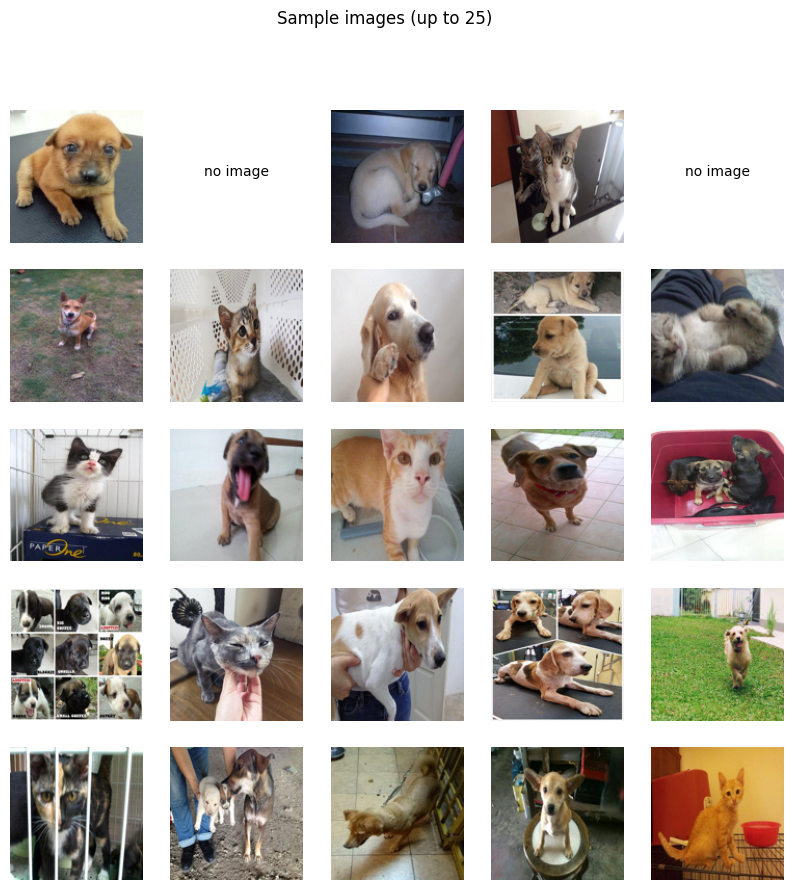

In [ ]:
# Image-based analysis 2: sample images per class and mean brightness
from PIL import Image

def get_image_path_for(petid):
    p1 = os.path.join(images_dir, f"{petid}-1.jpg")
    if os.path.exists(p1):
        return p1
    for f in glob.glob(os.path.join(images_dir, f"{petid}-*.jpg")):
        return f
    return None

sample_grid = {}
mean_brightness = []
for cls in sorted(train['AdoptionSpeed'].unique()):
    subset = train[train['AdoptionSpeed']==cls].sample(min(5, len(train[train['AdoptionSpeed']==cls])), random_state=SEED)
    imgs = []
    for pid in subset['PetID']:
        p = get_image_path_for(pid)
        if p:
            im = Image.open(p).convert('RGB')
            imgs.append(np.array(im.resize((128,128))).mean())
    mean_brightness.append({'cls':cls,'mean_brightness':np.mean(imgs) if imgs else np.nan})

print(pd.DataFrame(mean_brightness))

# show example images grid
fig, axes = plt.subplots(5,5, figsize=(10,10))
axes = axes.flatten()
idx = 0
for cls in sorted(train['AdoptionSpeed'].unique()):
    subset = train[train['AdoptionSpeed']==cls].sample(min(5, len(train[train['AdoptionSpeed']==cls])), random_state=SEED)
    for pid in subset['PetID']:
        p = get_image_path_for(pid)
        if p:
            im = Image.open(p).convert('RGB').resize((128,128))
            axes[idx].imshow(im)
        else:
            axes[idx].text(0.5,0.5,'no image',ha='center')
        axes[idx].axis('off')
        idx += 1
        if idx>=25: break
    if idx>=25: break
plt.suptitle('Sample images (up to 25)')
plt.show()


In [ ]:
# Additional statistical moments: skewness/kurtosis for PhotoAmt and Age
from scipy.stats import skew, kurtosis
print('PhotoAmt skew/kurt:', skew(train['PhotoAmt'].fillna(0)), kurtosis(train['PhotoAmt'].fillna(0)))
print('Age skew/kurt:', skew(train['Age'].fillna(0)), kurtosis(train['Age'].fillna(0)))


PhotoAmt skew/kurt: 2.8603518270840476 12.64130134495085
Age skew/kurt: 3.7625984439045688 20.764811474473962


In [ ]:
# Feature engineering (tabular preprocessing)
from sklearn.preprocessing import StandardScaler, LabelEncoder

def prepare_tabular(df, fit_scaler=None):
    out = df.copy()
    out['Breed2'] = out['Breed2'].fillna(0)
    out['Color2'] = out['Color2'].fillna(0)
    out['Color3'] = out['Color3'].fillna(0)
    out['Name'] = out['Name'].fillna('')
    resc_counts = out['RescuerID'].value_counts().to_dict()
    out['Rescuer_freq'] = out['RescuerID'].map(resc_counts).fillna(0)
    num_cols = ['Age','Quantity','Fee','PhotoAmt','VideoAmt','SentimentScore','SentimentMagnitude','Rescuer_freq','PhotoCount']
    out[num_cols] = out[num_cols].fillna(0)
    cat_cols = ['Type','Gender','MaturitySize','FurLength','Vaccinated','Dewormed','Sterilized','Health','State']
    for c in cat_cols:
        out[c] = out[c].fillna(0).astype(str)
        out[c+'_le'] = LabelEncoder().fit_transform(out[c])
    feat_cols = num_cols + [c+'_le' for c in cat_cols]
    if fit_scaler is None:
        scaler = StandardScaler()
        out[feat_cols] = scaler.fit_transform(out[feat_cols])
        return out, feat_cols, scaler
    else:
        out[feat_cols] = fit_scaler.transform(out[feat_cols])
        return out, feat_cols

train_pre, feat_cols, scaler = prepare_tabular(train)
print('features used:', feat_cols)
joblib.dump(scaler, 'scaler.joblib')


features used: ['Age', 'Quantity', 'Fee', 'PhotoAmt', 'VideoAmt', 'SentimentScore', 'SentimentMagnitude', 'Rescuer_freq', 'PhotoCount', 'Type_le', 'Gender_le', 'MaturitySize_le', 'FurLength_le', 'Vaccinated_le', 'Dewormed_le', 'Sterilized_le', 'Health_le', 'State_le']


['scaler.joblib']

In [ ]:
# Train/val/test split
train_df, temp_df = train_test_split(train_pre, test_size=0.30, random_state=SEED, stratify=train_pre['AdoptionSpeed'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['AdoptionSpeed'])
print('train/val/test sizes:', len(train_df), len(val_df), len(test_df))


train/val/test sizes: 10495 2249 2249


In [ ]:
# PyTorch Dataset + DataLoader
class PetDataset(Dataset):
    def __init__(self, df, feat_cols, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.feat_cols = feat_cols
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _get_image_path(self, petid):
        p1 = os.path.join(self.image_dir, f"{petid}-1.jpg")
        if os.path.exists(p1):
            return p1
        lst = glob.glob(os.path.join(self.image_dir, f"{petid}-*.jpg"))
        return lst[0] if lst else None

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        petid = row['PetID']
        img_path = self._get_image_path(petid)
        if img_path and os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
        else:
            img = torch.zeros(3,128,128)
        tab = torch.tensor(row[self.feat_cols].values.astype(np.float32))
        label = int(row['AdoptionSpeed'])
        return img, tab, label

train_transforms = transforms.Compose([
    transforms.Resize((128,128)),
    #transforms.RandomHorizontalFlip(),
    #transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
val_transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
# uzimamo samo 400 primera za brzi trening
train_df_small = train_df.sample(n=300, random_state=SEED)

train_ds = PetDataset(train_df_small, feat_cols, images_dir, transform=train_transforms)
val_ds = PetDataset(val_df, feat_cols, images_dir, transform=val_transforms)
test_ds = PetDataset(test_df, feat_cols, images_dir, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0)


In [ ]:
# Models: Image-only and Multimodal
class ImageOnlyModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        in_f = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.head = nn.Sequential(
            nn.Linear(in_f, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        feats = self.backbone(x)
        out = self.head(feats)
        return out

class MultimodalModel(nn.Module):
    def __init__(self, tab_input_dim, num_classes=5):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        in_f = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.tab_mlp = nn.Sequential(
            nn.Linear(tab_input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2)
        )
        self.fusion = nn.Sequential(
            nn.Linear(in_f + 128, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    def forward(self, image, tab):
        img_feat = self.backbone(image)
        tab_feat = self.tab_mlp(tab)
        x = torch.cat([img_feat, tab_feat], dim=1)
        return self.fusion(x)


In [ ]:
# Training and evaluation utilities
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    running_loss = 0.0
    y_true = []
    y_pred = []
    for images, tabs, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        tabs = tabs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        if isinstance(model, MultimodalModel):
            outputs = model(images, tabs)
        else:
            outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(labels.detach().cpu().numpy().tolist())
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc


def eval_model(model, loader, loss_fn):
    model.eval()
    running_loss = 0.0
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, tabs, labels in tqdm(loader, leave=False):
            images = images.to(DEVICE)
            tabs = tabs.to(DEVICE)
            labels = labels.to(DEVICE)
            if isinstance(model, MultimodalModel):
                outputs = model(images, tabs)
            else:
                outputs = model(images)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(labels.detach().cpu().numpy().tolist())
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    try:
        kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    except Exception:
        kappa = np.nan
    return avg_loss, acc, kappa, y_true, y_pred


def run_experiment(model, name, train_loader, val_loader, epochs=3, lr=1e-4):
    model = model.to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_kappa':[]}
    for ep in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, loss_fn)
        val_loss, val_acc, val_kappa, _, _ = eval_model(model, val_loader, loss_fn)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_kappa'].append(val_kappa)
        print(f"{name} Ep{ep+1}/{epochs} train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_kappa={val_kappa:.4f}")
    torch.save(model.state_dict(), f'{name}_model.pth')
    return model, history


In [ ]:
# Small sanity runs (set epochs small to verify)
# Image-only
img_model = ImageOnlyModel(num_classes=5)
img_model, hist_img = run_experiment(img_model, 'image_only', train_loader, val_loader, epochs=2, lr=1e-4)

# Multimodal
mm_model = MultimodalModel(tab_input_dim=len(feat_cols), num_classes=5)
mm_model, hist_mm = run_experiment(mm_model, 'multimodal', train_loader, val_loader, epochs=2, lr=1e-4)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 92.8MB/s]


  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

...

  0%|          | 0/282 [00:00<?, ?it/s]

multimodal Ep1/2 train_loss=1.5231 train_acc=0.2300 val_loss=1.4771 val_acc=0.2948 val_kappa=0.0907


  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

multimodal Ep2/2 train_loss=1.1547 train_acc=0.6033 val_loss=1.4964 val_acc=0.3072 val_kappa=0.1257


In [ ]:
# Evaluate on test set
loss_fn = nn.CrossEntropyLoss()
_, img_test_acc, img_test_kappa, y_true_img, y_pred_img = eval_model(img_model, test_loader, loss_fn)
print('Image-only test acc, kappa:', img_test_acc, img_test_kappa)

_, mm_test_acc, mm_test_kappa, y_true_mm, y_pred_mm = eval_model(mm_model, test_loader, loss_fn)
print('Multimodal test acc, kappa:', mm_test_acc, mm_test_kappa)


  0%|          | 0/282 [00:00<?, ?it/s]

Image-only test acc, kappa: 0.2681191640729213 0.04997152350523937


  0%|          | 0/282 [00:00<?, ?it/s]

Multimodal test acc, kappa: 0.28145842596709647 0.11166777803419725


In [ ]:
# ===============================
# LightGBM Tabular-only Baseline (sanity run)
# ===============================
import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import accuracy_score, cohen_kappa_score
import joblib

# --- Brzi sanity subset za trening ---
SUBSET_SIZE = 400  # manji broj primera da brzo trenira
train_df_small = train_df.sample(n=SUBSET_SIZE, random_state=SEED)

TAB_X = train_df_small[feat_cols]
TAB_y = train_df_small['AdoptionSpeed']

TAB_val_X = val_df[feat_cols]
TAB_val_y = val_df['AdoptionSpeed']

# --- Definisanje modela ---
clf = LGBMClassifier(
    objective='multiclass',
    num_class=5,
    learning_rate=0.05,
    num_leaves=31,
    n_estimators=200,
    random_state=SEED
)

# --- Callback lista ---
callbacks = [
    early_stopping(stopping_rounds=20),  # stop ako se validacija ne poboljsa 20 iteracija
    log_evaluation(period=20)            # ispisuje log svakih 20 iteracija
]

# --- Trening ---
try:
    clf.fit(
        TAB_X, TAB_y,
        eval_set=[(TAB_val_X, TAB_val_y)],
        callbacks=callbacks
    )

    # --- Predikcija ---
    val_pred_labels = clf.predict(TAB_val_X)

    # --- Metrike ---
    val_acc = accuracy_score(TAB_val_y, val_pred_labels)
    val_kappa = cohen_kappa_score(TAB_val_y, val_pred_labels, weights='quadratic')

    print(f'LightGBM val acc: {val_acc:.4f}, val kappa: {val_kappa:.4f}')

    # --- Čuvanje modela ---
    joblib.dump(clf, 'lightgbm_tabular.pkl')
    print("Model sačuvan: lightgbm_tabular.pkl")

except Exception as e:
    print('LightGBM training failed:', e)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000296 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 231
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 16
[LightGBM] [Info] Start training from score -3.688879
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.272966
[LightGBM] [Info] Start training from score -1.502828
[LightGBM] [Info] Start training from score -1.300117
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Train

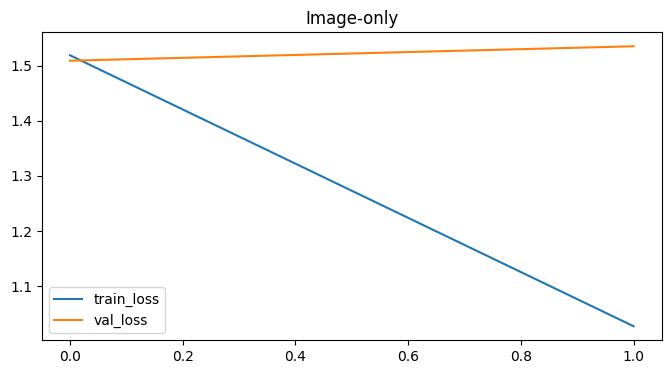

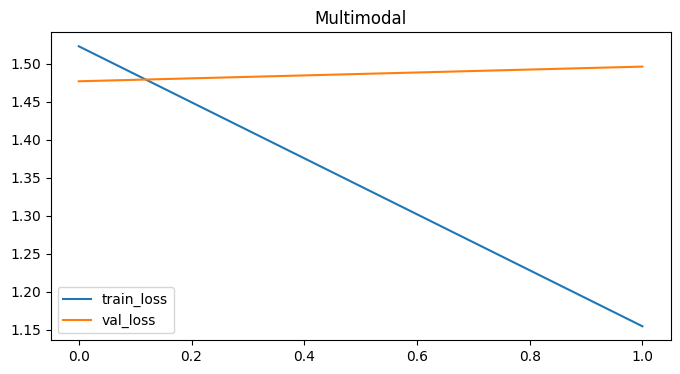

In [ ]:
# Plot training curves helper
def plot_history(hist, title='Training curves'):
    plt.figure(figsize=(8,4))
    plt.plot(hist['train_loss'], label='train_loss')
    plt.plot(hist['val_loss'], label='val_loss')
    plt.legend()
    plt.title(title)
    plt.show()

plot_history(hist_img, 'Image-only')
plot_history(hist_mm, 'Multimodal')


In [ ]:
# Save artifacts
os.makedirs('artifacts', exist_ok=True)
joblib.dump(feat_cols, 'artifacts/feat_cols.joblib')
joblib.dump(scaler, 'artifacts/scaler.joblib')
print('Saved artifacts in ./artifacts and models in ./')


Saved artifacts in ./artifacts and models in ./
